## Cell 1 - Cai thu vien


In [3]:
import subprocess, sys
subprocess.run([sys.executable,'-m','pip','install','-q',
    'numpy','pandas','matplotlib','scikit-learn','torch','scipy','implicit'], check=True)
import os, math, warnings, time
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from sklearn.preprocessing import normalize
from numpy.linalg import inv
from IPython.display import display
warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print('Import OK')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 99.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 108.9 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

Device: cuda
Import OK


## Cell 2 - Load user_portfolios.csv


In [4]:
CSV_PATH = '/kaggle/input/datasets/huyhung2004/rs-data/USER_PORTFOLIOS.csv'  # chinh duong dan neu can

df_raw = pd.read_csv(CSV_PATH)
df_raw.columns = [c.strip().upper() for c in df_raw.columns]

print('Cot trong file:', df_raw.columns.tolist())
print(f'So dong: {len(df_raw):,}')
display(df_raw.head(5))

# Chuan hoa ten cot
df_raw = df_raw.rename(columns={
    'USER_ID' : 'user_id',
    'TOKEN_ID': 'token_id',
    'TX_COUNT': 'tx_count',
    'BALANCE' : 'balance',
})
df_raw['user_id']  = df_raw['user_id'].astype(str).str.strip()
df_raw['token_id'] = df_raw['token_id'].astype(str).str.strip()
df_raw['tx_count'] = pd.to_numeric(df_raw.get('tx_count', 1), errors='coerce').fillna(1)
df_raw['balance']  = pd.to_numeric(df_raw.get('balance',  0), errors='coerce').fillna(0.0)

# Loc: chi giu token dang nam giu (balance > 0) va co giao dich
df_raw = df_raw[
    df_raw['balance']  > 0
].dropna(subset=['user_id','token_id']).copy()

print(f'\nSau loc (balance > 0):')
print(f'  Rows  : {len(df_raw):,}')
print(f'  Users : {df_raw["user_id"].nunique():,}')
print(f'  Tokens: {df_raw["token_id"].nunique():,}')


Cot trong file: ['TOKEN_ID', 'USER_ID', 'BALANCE', 'TX_COUNT', 'LAST_ACTIVE']
So dong: 2,274,180


,TOKEN_ID,USER_ID,BALANCE,TX_COUNT,LAST_ACTIVE
0,37651,11459558,1.134885e-02,9,2025-09-27 09:47:05.000
1,54168,13824590,2.500000e-02,1,2025-12-02 09:09:11.000
2,130149,13824590,1.000000e-07,1,2025-09-08 01:37:35.000
3,9179,28247232,1.132514e+01,1,2026-03-20 18:49:59.000
4,130149,12703125,1.000000e-07,1,2025-08-30 20:08:23.000



Sau loc (balance > 0):
  Rows  : 2,274,180
  Users : 611,253
  Tokens: 381


## Cell 3 & 4 - Gom nhóm, Tính Edge Weight & Lọc (Cập nhật)


In [5]:
df = df_raw.groupby(['user_id', 'token_id'], as_index=False).agg(tx_count=('tx_count', 'sum'))

def scale_0_1(series):
    max_value = series.max()
    if pd.isna(max_value) or max_value <= 0: return series * 0.0
    return series / max_value

df['edge_weight'] = scale_0_1(np.log1p(df['tx_count'].clip(lower=0))).astype(np.float32)

MIN_USER_TOKENS = 3
MIN_TOKEN_HOLDERS = 2
user_counts = df.groupby('user_id')['token_id'].transform('nunique')
token_counts = df.groupby('token_id')['user_id'].transform('nunique')
df = df[(user_counts >= MIN_USER_TOKENS) & (token_counts >= MIN_TOKEN_HOLDERS)].copy()

user_list  = sorted(df['user_id'].unique())
token_list = sorted(df['token_id'].unique())
user2idx   = {u:i for i,u in enumerate(user_list)}
token2idx  = {t:i for i,t in enumerate(token_list)}
idx2user   = dict(enumerate(user_list))
idx2token  = dict(enumerate(token_list))

df['u_idx'] = df['user_id'].map(user2idx)
df['t_idx'] = df['token_id'].map(token2idx)

N_USERS  = len(user_list)
N_TOKENS = len(token_list)

print(f'Sau khi lọc: {len(df):,} interactions | {N_USERS:,} users | {N_TOKENS:,} tokens')
display(df[['user_id', 'token_id', 'tx_count', 'edge_weight']].head(5))


Sau khi lọc: 2,009,514 interactions | 464,423 users | 381 tokens


,user_id,token_id,tx_count,edge_weight
0,10,130149,1,0.075308
1,10,147692,19,0.325474
2,10,26553,3,0.150615
3,10,31100,1,0.075308
4,10,97321,13,0.286722


## Cell 5 - Train/Test Split (Leave-One-Out)


In [6]:
import random
random.seed(42); np.random.seed(42)

# LOO: giu 1 token ngau nhien cua moi user lam ground truth
train_rows, test_rows = [], []
loo_gt = {}  # u_idx -> token_idx

for u, grp in df.groupby('u_idx'):
    if len(grp) >= 3:
        test_row  = grp.sample(1, random_state=u).index[0]
        test_rows.append(test_row)
        train_rows.extend(i for i in grp.index if i != test_row)
        loo_gt[u] = int(df.loc[test_row, 't_idx'])
    else:
        train_rows.extend(grp.index.tolist())

df_train = df.loc[train_rows].copy().reset_index(drop=True)

# Seen items (loai khoi goi y)
user_seen = df_train.groupby('u_idx')['t_idx'].apply(set).to_dict()

# Sparse matrix
X_train = sp.csr_matrix(
    (df_train['edge_weight'].values,
     (df_train['u_idx'].values, df_train['t_idx'].values)),
    shape=(N_USERS, N_TOKENS), dtype=np.float32
)
print(f'Train edges: {len(df_train):,}')
print(f'LOO users  : {len(loo_gt):,}')
print(f'X_train nnz: {X_train.nnz:,}')

# Ham danh gia chung
def evaluate(score_fn, loo_gt, user_seen,
             K_list=[5,10,20], sample_n=3000):
    rng  = np.random.default_rng(42)
    uids = list(loo_gt.keys())
    if len(uids) > sample_n:
        uids = rng.choice(uids, sample_n, replace=False).tolist()
    res  = {K:{'hit':[],'ndcg':[],'prec':[],'rec':[]} for K in K_list}
    maxK = max(K_list)
    for u in uids:
        gt = loo_gt[u]
        sc = score_fn(u).copy()
        for s in user_seen.get(u, set()): sc[s] = -np.inf
        top = np.argpartition(sc,-maxK)[-maxK:]
        top = top[np.argsort(sc[top])[::-1]]
        for K in K_list:
            topk = top[:K].tolist()
            hit  = 1 if gt in topk else 0
            rank = topk.index(gt)+1 if hit else K+1
            res[K]['hit'].append(hit)
            res[K]['ndcg'].append(1/math.log2(rank+1) if hit else 0.)
            res[K]['prec'].append(hit/K)
            res[K]['rec'].append(float(hit))
    n = max(len(res[K_list[0]]['hit']),1)
    out = {'n':n}
    for K in K_list:
        out[f'Hit@{K}']    = round(np.mean(res[K]['hit']),4)
        out[f'NDCG@{K}']   = round(np.mean(res[K]['ndcg']),4)
        out[f'Prec@{K}']   = round(np.mean(res[K]['prec']),4)
        out[f'Recall@{K}'] = round(np.mean(res[K]['rec']),4)
    return out

all_results = {}
print('Chuan bi xong, san sang train 3 model!')


Train edges: 1,545,091
LOO users  : 464,423
X_train nnz: 1,545,091
Chuan bi xong, san sang train 3 model!


## Cell 6 - Model 1: EASE

Khong train, chi nghich dao ma tran 1 lan. Grid search lambda tu dong.


In [7]:
t0 = time.time()

def ease_fit(X, lam):
    G = np.array((X.T @ X).todense(), dtype=np.float64) + lam*np.eye(X.shape[1])
    P = inv(G)
    B = -P / np.diag(P)
    np.fill_diagonal(B, 0.)
    return B.astype(np.float32)

# Grid search tren 300 user mau
rng_gs   = np.random.default_rng(0)
gs_users = {u:loo_gt[u] for u in
            rng_gs.choice(list(loo_gt.keys()), min(300,len(loo_gt)), replace=False)}

print('Grid search lambda:')
best_lam, best_ndcg, B_ease = 500, -1, None
for lam in [50, 100, 200, 500, 1000, 2000, 5000]:
    B_tmp = ease_fit(X_train, lam)
    X_d   = np.array(X_train[list(gs_users.keys())].todense(), dtype=np.float32)
    def fn_gs(u, B=B_tmp): return np.array(X_train[u].todense()).flatten() @ B
    m = evaluate(fn_gs, gs_users, user_seen, K_list=[10])
    mark = ' <-- best' if m['NDCG@10'] > best_ndcg else ''
    print(f'  lambda={lam:5d}  NDCG@10={m["NDCG@10"]:.4f}{mark}')
    if m['NDCG@10'] > best_ndcg:
        best_ndcg, best_lam, B_ease = m['NDCG@10'], lam, B_tmp.copy()

def ease_score(u): return np.array(X_train[u].todense()).flatten() @ B_ease
all_results['EASE'] = evaluate(ease_score, loo_gt, user_seen)
print(f'\nEASE (lambda={best_lam}) trong {time.time()-t0:.1f}s')
print(f'  Hit@10={all_results["EASE"]["Hit@10"]:.4f}  '
      f'NDCG@10={all_results["EASE"]["NDCG@10"]:.4f}  '
      f'Prec@10={all_results["EASE"]["Prec@10"]:.4f}')


Grid search lambda:
  lambda=   50  NDCG@10=0.3672 <-- best
  lambda=  100  NDCG@10=0.3693 <-- best
  lambda=  200  NDCG@10=0.3703 <-- best
  lambda=  500  NDCG@10=0.3708 <-- best
  lambda= 1000  NDCG@10=0.3760 <-- best
  lambda= 2000  NDCG@10=0.3763 <-- best
  lambda= 5000  NDCG@10=0.3747

EASE (lambda=2000) trong 1.5s
  Hit@10=0.5573  NDCG@10=0.3770  Prec@10=0.0557


## Cell 7 - Model 2: ItemKNN

Goi y dua tren do tuong dong cosine giua cac token.
'Vi A cam ETH → ETH giong AAVE (80% nguoi cam ETH cung cam AAVE) → goi y AAVE'


In [8]:
t0 = time.time()

# Tinh cosine similarity giua token (N_TOKENS x N_TOKENS)
X_t = X_train.T.toarray().astype(np.float32)   # (N_TOKENS, N_USERS)
norms = np.linalg.norm(X_t, axis=1, keepdims=True).clip(min=1e-9)
X_t_norm  = X_t / norms
S_item    = X_t_norm @ X_t_norm.T              # (N_TOKENS, N_TOKENS)
np.fill_diagonal(S_item, 0.)

# Tinh trc score cho tat ca user (N_USERS, N_TOKENS)
X_dense    = X_train.toarray().astype(np.float32)
scores_knn = X_dense @ S_item

def knn_score(u): return scores_knn[u]
all_results['ItemKNN'] = evaluate(knn_score, loo_gt, user_seen)
print(f'ItemKNN trong {time.time()-t0:.1f}s')
print(f'  Hit@10={all_results["ItemKNN"]["Hit@10"]:.4f}  '
      f'NDCG@10={all_results["ItemKNN"]["NDCG@10"]:.4f}  '
      f'Prec@10={all_results["ItemKNN"]["Prec@10"]:.4f}')

# Hien thi token giong nhau nhat
print(f'\nTop 5 token tuong dong voi Token [{idx2token[0]}]:')
for t in np.argsort(S_item[0])[::-1][:5]:
    print(f'  {idx2token[t]}: sim={S_item[0,t]:.4f}')


ItemKNN trong 3.9s
  Hit@10=0.5503  NDCG@10=0.3949  Prec@10=0.0550

Top 5 token tuong dong voi Token [100362]:
  64487: sim=0.2345
  156235: sim=0.1844
  93964: sim=0.1571
  134959: sim=0.1546
  148617: sim=0.1388


## Cell 8 - Model 3: BPR (Bayesian Personalized Ranking)

Dùng BPR từ thư viện implicit thay thế cho ALS/LightGCN.


In [9]:
import implicit
import time

print('Training BPR Model...')
t0 = time.time()

# Khởi tạo mô hình BPR
model_bpr = implicit.bpr.BayesianPersonalizedRanking(
    factors=128,
    learning_rate=0.01,
    regularization=0.01,
    iterations=50,
    random_state=42
)

model_bpr.fit(X_train)

USER_EMB = model_bpr.user_factors
ITEM_EMB = model_bpr.item_factors

scores_bpr = USER_EMB @ ITEM_EMB.T
def bpr_score(u): return scores_bpr[u]

all_results['BPR'] = evaluate(bpr_score, loo_gt, user_seen)
print(f'\nBPR trong {time.time()-t0:.1f}s')
print(f'  Hit@10={all_results["BPR"]["Hit@10"]:.4f}  '
      f'NDCG@10={all_results["BPR"]["NDCG@10"]:.4f}  '
      f'Prec@10={all_results["BPR"]["Prec@10"]:.4f}')


Training BPR Model...


  0%|          | 0/50 [00:00<?, ?it/s]


BPR trong 18.3s
  Hit@10=0.2117  NDCG@10=0.1819  Prec@10=0.0212


## Cell 8.5 - Model 4: NCF (Neural Collaborative Filtering - Học Sâu)

Sử dụng Mạng Nơ-ron Nhân tạo (PyTorch) để học các tương tác phi tuyến tính phức tạp giữa User và Token, thay vì chỉ là tích vô hướng tuyến tính.


In [10]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class NCF(nn.Module):
    def __init__(self, num_users, num_items, embed_dim=32):
        super().__init__()
        self.user_emb = nn.Embedding(num_users, embed_dim)
        self.item_emb = nn.Embedding(num_items, embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim * 2, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, u, i):
        u_emb = self.user_emb(u)
        i_emb = self.item_emb(i)
        cat = torch.cat([u_emb, i_emb], dim=-1)
        return self.mlp(cat).squeeze()

# Chuẩn bị dữ liệu (Negative Sampling)
u_train = torch.tensor(df_train['u_idx'].values, dtype=torch.long)
i_train = torch.tensor(df_train['t_idx'].values, dtype=torch.long)
y_train = torch.ones(len(df_train), dtype=torch.float32)

neg_u, neg_i = [], []
for _ in range(4):  # Tạo 4 mẫu negative cho mỗi 1 mẫu positive
    neg_u.extend(u_train.tolist())
    neg_i.extend(np.random.randint(0, N_TOKENS, len(u_train)))

u_train = torch.cat([u_train, torch.tensor(neg_u, dtype=torch.long)])
i_train = torch.cat([i_train, torch.tensor(neg_i, dtype=torch.long)])
y_train = torch.cat([y_train, torch.zeros(len(neg_u), dtype=torch.float32)])

dataset = TensorDataset(u_train, i_train, y_train)
loader = DataLoader(dataset, batch_size=4096, shuffle=True)

model_ncf = NCF(N_USERS, N_TOKENS).to(DEVICE)
optimizer = optim.Adam(model_ncf.parameters(), lr=0.01)
criterion = nn.BCEWithLogitsLoss()

print(f'Training NCF (Deep Learning) on {DEVICE}...')
t0 = time.time()
model_ncf.train()
for ep in range(10):
    total_loss = 0
    for bu, bi, by in loader:
        bu, bi, by = bu.to(DEVICE), bi.to(DEVICE), by.to(DEVICE)
        optimizer.zero_grad()
        out = model_ncf(bu, bi)
        loss = criterion(out, by)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (ep+1) % 2 == 0:
        print(f"  Epoch {ep+1:2d}/10 | Loss: {total_loss/len(loader):.4f}")

# =========================================================
# PHẦN ĐÃ SỬA: Tránh CUDA Out of Memory bằng vòng lặp User
# =========================================================
model_ncf.eval()
# Tạo sẵn ma trận Numpy trên CPU để hứng kết quả
scores_ncf_tensor = np.zeros((N_USERS, N_TOKENS), dtype=np.float32)

with torch.no_grad():
    all_i = torch.arange(N_TOKENS, device=DEVICE)
    for u in range(N_USERS):
        # Tạo tensor gồm toàn ID của user u hiện tại
        u_tensor = torch.full((N_TOKENS,), u, dtype=torch.long, device=DEVICE)
        
        # Dự đoán điểm cho user u với tất cả items
        scores = model_ncf(u_tensor, all_i)
        
        # Đưa kết quả từ GPU về CPU và gán vào ma trận
        scores_ncf_tensor[u] = scores.cpu().numpy()

def ncf_score(u): 
    return scores_ncf_tensor[u]

all_results['NCF'] = evaluate(ncf_score, loo_gt, user_seen)
print(f'\nNCF trong {time.time()-t0:.1f}s')
print(f'  Hit@10={all_results["NCF"]["Hit@10"]:.4f}  '
      f'NDCG@10={all_results["NCF"]["NDCG@10"]:.4f}  '
      f'Prec@10={all_results["NCF"]["Prec@10"]:.4f}')

Training NCF (Deep Learning) on cuda...
  Epoch  2/10 | Loss: 0.2479
  Epoch  4/10 | Loss: 0.1394
  Epoch  6/10 | Loss: 0.0655
  Epoch  8/10 | Loss: 0.0453
  Epoch 10/10 | Loss: 0.0362

NCF trong 1367.8s
  Hit@10=0.3513  NDCG@10=0.2410  Prec@10=0.0351


## Cell 9 - So sanh 3 model & Chon model tot nhat


Metric                    EASE         ItemKNN             BPR             NCF
------------------------------------------------------------------------------
Prec@5                0.1001          0.1003 *        0.0399          0.0569  
Recall@5              0.5007          0.5017 *        0.1997          0.2847  
Hit@5                 0.5007          0.5017 *        0.1997          0.2847  
NDCG@5                0.3586          0.3793 *        0.1780          0.2195  
Prec@10               0.0557 *        0.0550          0.0212          0.0351  
Recall@10             0.5573 *        0.5503          0.2117          0.3513  
Hit@10                0.5573 *        0.5503          0.2117          0.3513  
NDCG@10               0.3770          0.3949 *        0.1819          0.2410  
Prec@20               0.0310 *        0.0307          0.0121          0.0227  
Recall@20             0.6203 *        0.6143          0.2427          0.4547  
Hit@20                0.6203 *        0.6143        

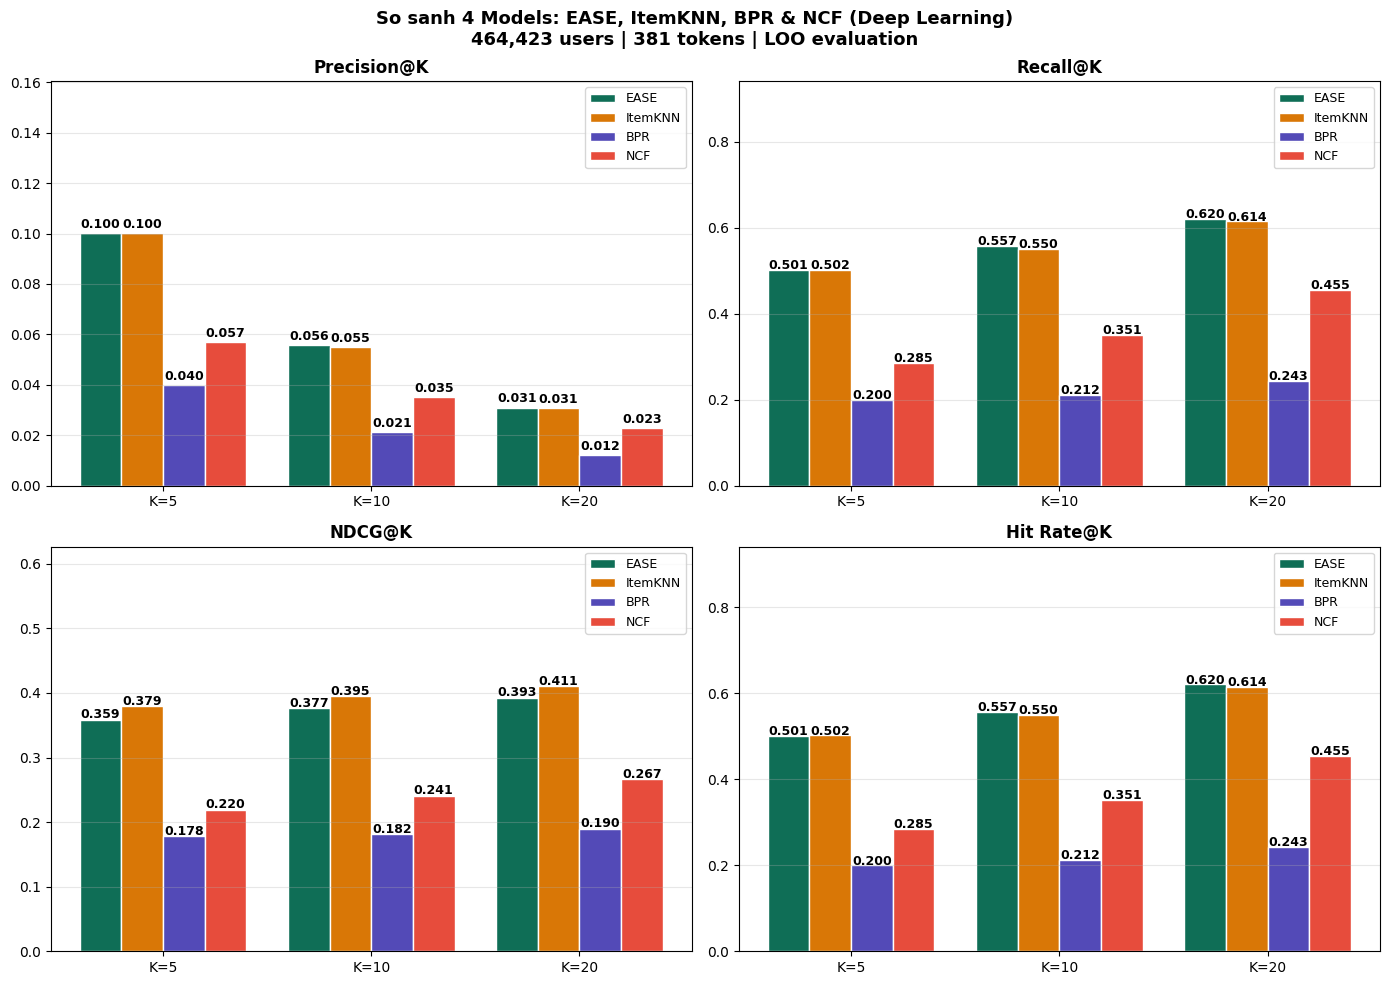


Best model theo NDCG@10: ItemKNN
  Hit@10        : 0.5503
  NDCG@10       : 0.3949
  Prec@10       : 0.0550
  Recall@10     : 0.5503


In [11]:
KS     = [5, 10, 20]
models = [m for m in ['EASE','ItemKNN','BPR','NCF'] if m in all_results]
colors = ['#0F6E56','#D97706','#534AB7', '#E74C3C']

# Bang ket qua
all_keys = [f'{m}@{k}' for k in KS for m in ['Prec','Recall','Hit','NDCG']]
cw = 16
print('='*(14+cw*len(models)))
print(f'{"Metric":<14}', end='')
for mn in models: print(f'{mn:>{cw}}', end='')
print('\n'+'-'*(14+cw*len(models)))
for key in all_keys:
    vals = [all_results[mn].get(key,0) for mn in models]
    best = max(vals)
    print(f'{key:<14}', end='')
    for v in vals:
        star = ' *' if v==best else '  '
        print(f'{v:>{cw-2}.4f}{star}', end='')
    print()
print('='*(14+cw*len(models)))

# Chart
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'So sanh 4 Models: EASE, ItemKNN, BPR & NCF (Deep Learning)\n'
             f'{N_USERS:,} users | {N_TOKENS} tokens | LOO evaluation',
             fontsize=13, fontweight='bold')
axes = axes.flatten()
x = np.arange(len(KS)); w = 0.8/len(models)
for ax, (title, mk) in zip(axes,[
    ('Precision@K','Prec'),('Recall@K','Recall'),
    ('NDCG@K','NDCG'),('Hit Rate@K','Hit')]):
    for j,(mn,c) in enumerate(zip(models,colors)):
        vals = [all_results[mn].get(f'{mk}@{k}',0) for k in KS]
        bars = ax.bar(x+j*w, vals, w, label=mn, color=c, edgecolor='white')
        for b,v in zip(bars,vals):
            ax.text(b.get_x()+b.get_width()/2, v+.002, f'{v:.3f}',
                    ha='center', fontsize=9, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x+w*(len(models)-1)/2)
    ax.set_xticklabels([f'K={k}' for k in KS])
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
    av = [all_results[mn].get(f'{mk}@{k}',0) for mn in models for k in KS]
    ax.set_ylim(0, max(av)*1.5+.01)
plt.tight_layout()
plt.savefig('comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Ket luan
best_mn = max(all_results, key=lambda m: all_results[m].get('NDCG@10',0))
print(f'\nBest model theo NDCG@10: {best_mn}')
for k in [f'Hit@10','NDCG@10','Prec@10','Recall@10']:
    print(f'  {k:<14}: {all_results[best_mn][k]:.4f}')


## Cell 10 - Luu Embeddings cho LSH


In [12]:
import os

os.makedirs('lsh_inputs', exist_ok=True)

# Chon embedding cua best model
if best_mn == 'BPR':
    U_final = USER_EMB   # (N_USERS, 128)
    V_final = ITEM_EMB   # (N_TOKENS, 128)
elif best_mn == 'EASE':
    # EASE: dung SVD cua B de lay 64-dim embedding
    from scipy.sparse.linalg import svds
    U_svd, S_svd, Vt = np.linalg.svd(B_ease, full_matrices=False)
    V_final = (U_svd[:,:64] * np.sqrt(S_svd[:64])).astype(np.float32)
    X_norm  = X_train.toarray().astype(np.float32)
    X_norm  = X_norm / (X_norm.sum(axis=1, keepdims=True).clip(min=1e-9))
    U_final = (X_norm @ V_final).astype(np.float32)
else:  # ItemKNN
    # ItemKNN: dung SVD cua similarity matrix
    U_svd, S_svd, Vt = np.linalg.svd(S_item, full_matrices=False)
    V_final = (U_svd[:,:64] * np.sqrt(np.abs(S_svd[:64]))).astype(np.float32)
    X_norm  = X_train.toarray().astype(np.float32)
    X_norm  = X_norm / (X_norm.sum(axis=1, keepdims=True).clip(min=1e-9))
    U_final = (X_norm @ V_final).astype(np.float32)

DIM_OUT = U_final.shape[1]
fcols   = [f'f{i}' for i in range(DIM_OUT)]

df_uf = pd.DataFrame(U_final, columns=fcols)
df_uf.insert(0,'user_idx', range(N_USERS))
df_uf.insert(1,'user_id',  user_list)

df_vf = pd.DataFrame(V_final, columns=fcols)
df_vf.insert(0,'token_idx', range(N_TOKENS))
df_vf.insert(1,'token_id',  token_list)

df_uf.to_parquet('lsh_inputs/user_factors.parquet',  index=False)
df_vf.to_parquet('lsh_inputs/item_factors.parquet',  index=False)
pd.DataFrame({'user_idx':range(N_USERS),'user_id':user_list}
            ).to_parquet('lsh_inputs/user_id_map.parquet',   index=False)
pd.DataFrame({'token_idx':range(N_TOKENS),'token_id':token_list}
            ).to_parquet('lsh_inputs/token_id_map.parquet',  index=False)

print(f'Best model   : {best_mn}')
print(f'User Factors : {df_uf.shape}  -> lsh_inputs/user_factors.parquet')
print(f'Item Factors : {df_vf.shape}  -> lsh_inputs/item_factors.parquet')
print(f'NDCG@10      : {all_results[best_mn]["NDCG@10"]:.4f}')
print(f'Hit@10       : {all_results[best_mn]["Hit@10"]:.4f}')


Best model   : ItemKNN
User Factors : (464423, 66)  -> lsh_inputs/user_factors.parquet
Item Factors : (381, 66)  -> lsh_inputs/item_factors.parquet
NDCG@10      : 0.3949
Hit@10       : 0.5503


Đang vẽ biểu đồ riêng cho từng mô hình...


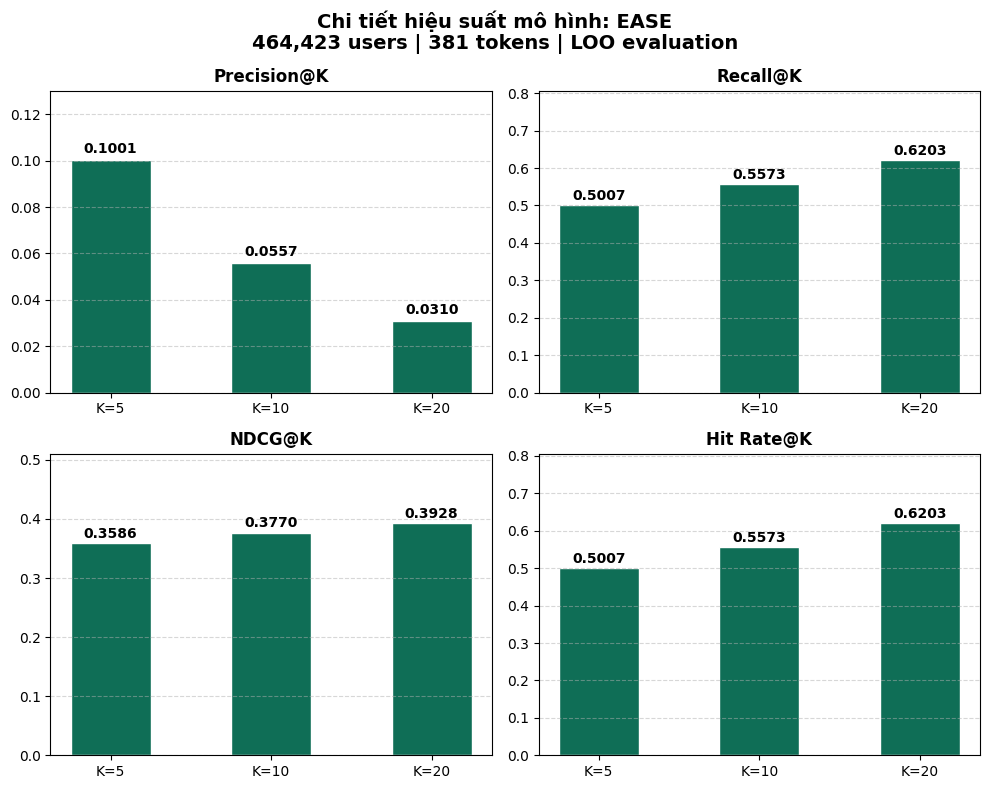

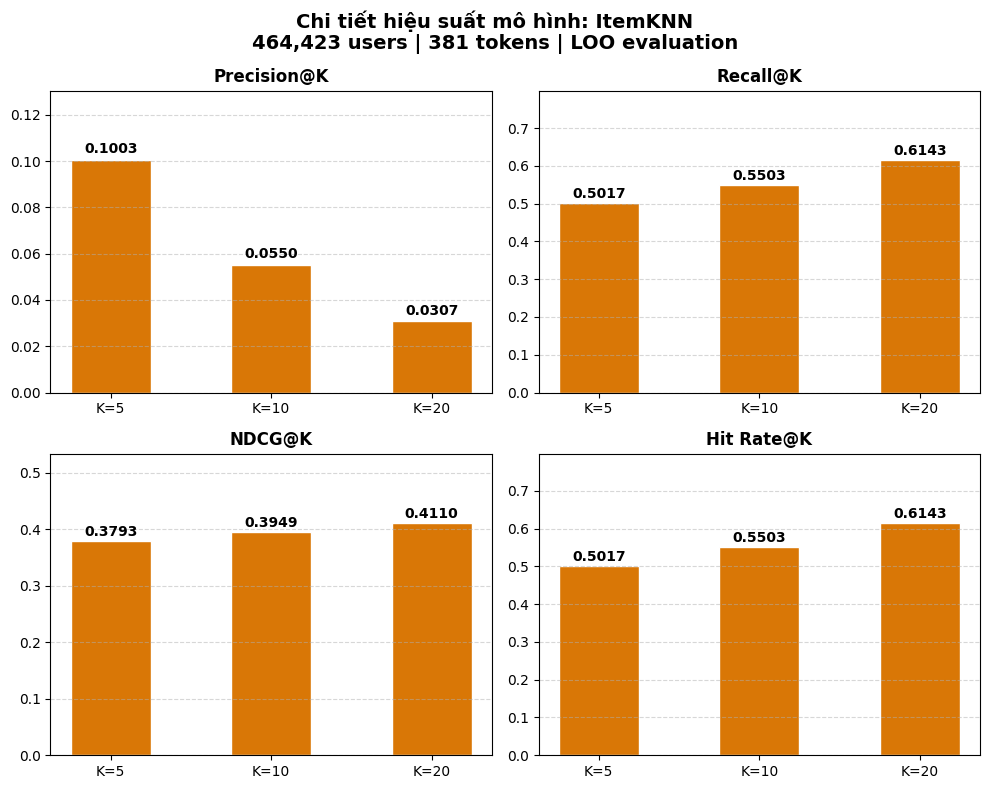

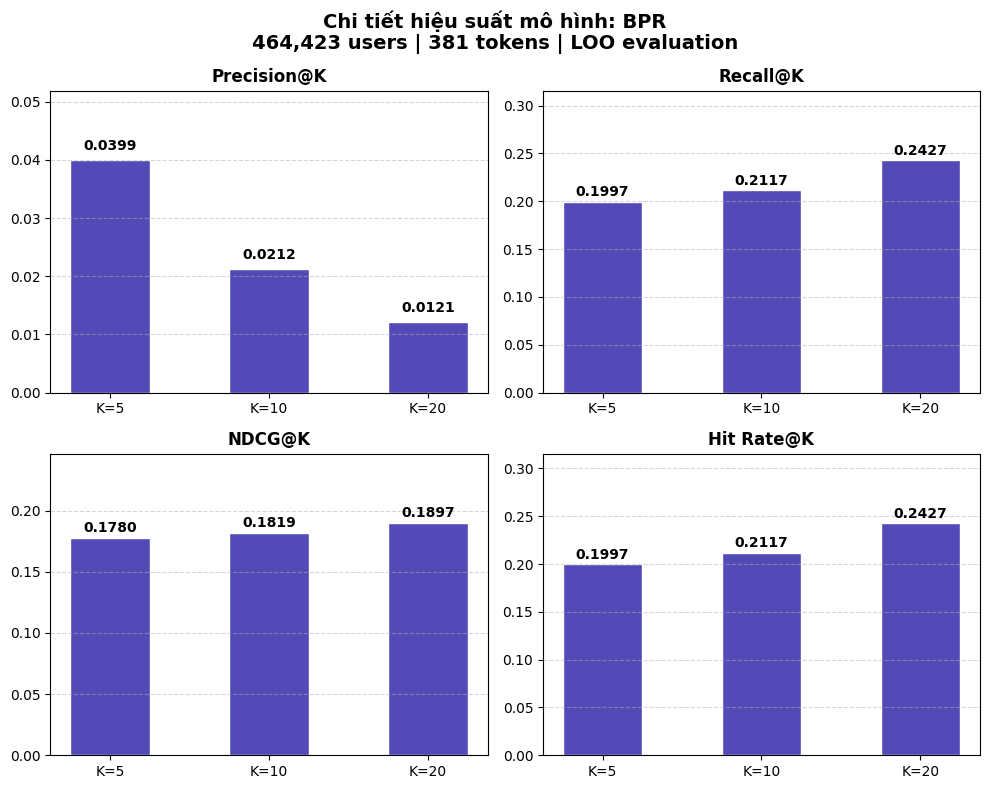

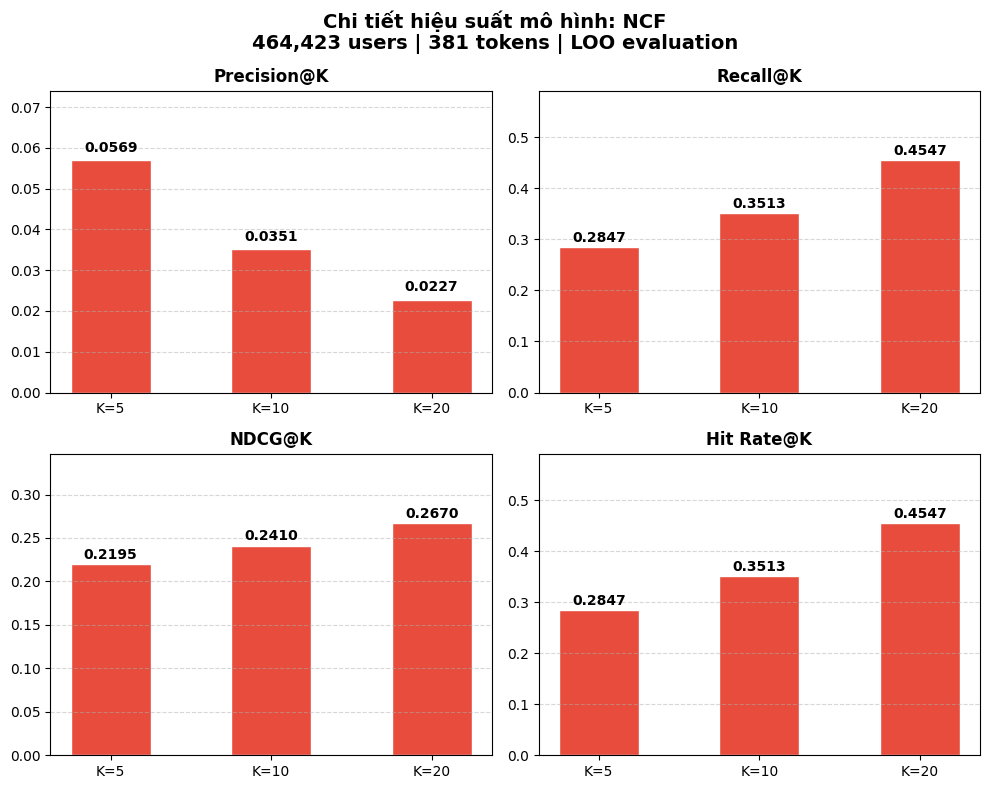


Best model theo NDCG@10: ItemKNN
  Hit@10        : 0.5503
  NDCG@10       : 0.3949
  Prec@10       : 0.0550
  Recall@10     : 0.5503


In [13]:
import matplotlib.pyplot as plt
import numpy as np

KS = [5, 10, 20]
models = [m for m in ['EASE', 'ItemKNN', 'BPR', 'NCF'] if m in all_results]
metric_keys = [('Precision@K', 'Prec'), ('Recall@K', 'Recall'), ('NDCG@K', 'NDCG'), ('Hit Rate@K', 'Hit')]

# Màu sắc riêng biệt để phân biệt các mô hình khi nhìn nhanh
model_colors = {'EASE': '#0F6E56', 'ItemKNN': '#D97706', 'BPR': '#534AB7', 'NCF': '#E74C3C'}

print("Đang vẽ biểu đồ riêng cho từng mô hình...")

# Lặp qua từng mô hình và vẽ 1 Figure riêng cho nó
for mn in models:
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    fig.suptitle(f'Chi tiết hiệu suất mô hình: {mn}\n'
                 f'{N_USERS:,} users | {N_TOKENS} tokens | LOO evaluation',
                 fontsize=14, fontweight='bold')
    
    axes = axes.flatten()
    x = np.arange(len(KS))
    w = 0.5  # Độ rộng của cột
    color = model_colors.get(mn, '#1f77b4') # Lấy màu theo mô hình

    for i, (title, mk) in enumerate(metric_keys):
        ax = axes[i]
        # Lấy dữ liệu thật từ all_results
        vals = [all_results[mn].get(f'{mk}@{k}', 0) for k in KS]
        
        # Vẽ cột
        bars = ax.bar(x, vals, w, color=color, edgecolor='white')

        # Hiển thị số liệu trên đầu cột
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width()/2, v + (max(vals)*0.02) + 0.001, f'{v:.4f}',
                    ha='center', fontsize=10, fontweight='bold')

        ax.set_title(title, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([f'K={k}' for k in KS])
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        
        # Chỉnh lại trục Y cho thoáng để không bị cắt chữ
        if max(vals) > 0:
            ax.set_ylim(0, max(vals) * 1.3)

    plt.tight_layout()
    # Lưu riêng từng file ảnh nếu cần: plt.savefig(f'chart_{mn}.png', dpi=150)
    plt.show()

# ==========================================
# Phần Kết luận (Giữ nguyên như của bạn)
# ==========================================
best_mn = max(all_results, key=lambda m: all_results[m].get('NDCG@10',0))
print(f'\nBest model theo NDCG@10: {best_mn}')
for k in [f'Hit@10','NDCG@10','Prec@10','Recall@10']:
    print(f'  {k:<14}: {all_results[best_mn].get(k, 0):.4f}')